# E25 · Joint models: a longitudinal biomarker and survival, linked by shared latent effects

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Mayo Clinic trial in primary biliary cholangitis (PBC), 1974-1984: 312 patients randomised to D-penicillamine or placebo, 1945 serum bilirubin measurements, follow-up to 1986 (`pbcseq` from the R package `survival`) |
| **You will learn** | Why "baseline value" and "last value carried forward" survival models mis-state a biomarker's effect · informative dropout: why the observed average trajectory lies · a joint model = a mixed model for the biomarker + a hazard driven by the patient's *latent* current value, sharing the random effects · the cumulative hazard as an integral, done with Gauss-Legendre quadrature after a change of variables, checked against SciPy and a closed form · centred, non-centred and *hierarchically* centred random effects compared (no divergences anywhere, a 20-fold difference in ESS) · two-stage plug-in estimates are attenuated and over-confident · dynamic predictions that update as new measurements arrive, on held-out patients · a landmark calibration check |

E06 treated survival time as the outcome and the covariates as fixed numbers measured once.
Clinical reality is messier. A patient with a chronic liver disease visits the clinic every
few months, and every visit produces a lab value - here **serum bilirubin**, the classic
marker of how well the liver clears waste. Doctors watch the trajectory, and the natural
question is: *how does the risk of death depend on where the patient's bilirubin is now,
and what does a new measurement tell us about this particular patient's prognosis?*

Both halves of the data are awkward. The biomarker is measured with noise, at irregular
times, and it stops being measured when the patient dies - so the sickest patients leave the
longitudinal data early. The survival outcome depends on a covariate that changes over time
and is never observed exactly. A **joint model** handles both at once: a hierarchical model
(E02) describes each patient's true, latent bilirubin trajectory, and the hazard (E06) is a
function of that latent trajectory. The two submodels share the patient's random effects, so
every measurement informs the survival prediction and every death informs the trajectory.

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy import integrate

from pymc_challenges import data

RANDOM_SEED = 25
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no banner per fit
BLUE, ORANGE, AQUA, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#c8374a"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The trial and its two kinds of data

Between 1974 and 1984 the Mayo Clinic randomised 312 patients with primary biliary
cholangitis (then called primary biliary cirrhosis), a slowly progressive autoimmune liver
disease, to D-penicillamine or placebo. The `pbcseq` table has one row per clinic visit:
the lab values measured at that visit (`day` since enrolment) and, repeated on every row,
the patient's follow-up time `futime` and final `status` (0 = alive at last contact,
1 = liver transplant, 2 = death).

In [2]:
data.describe("pbcseq")
visits = data.load("pbcseq")
visits["t"] = visits.day / 365.25            # years since enrolment
visits["y"] = np.log(visits.bili)            # log bilirubin: the biomarker we model
patients = visits.groupby("id").agg(
    T=("futime", "first"), status=("status", "first"), trt=("trt", "first"),
    age=("age", "first"), n_visits=("day", "size"), y0=("y", "first"),
)
patients["T"] /= 365.25
patients.groupby("status").agg(
    patients=("T", "size"), mean_followup_years=("T", "mean"), mean_visits=("n_visits", "mean"),
).rename(index={0: "censored", 1: "transplant", 2: "died"}).round(1)

pbcseq: 1945 visits of the 312 randomised patients: serum bilirubin (mg/dl) and other labs at each `day`, plus follow-up `futime` (days) and `status` (0 censored, 1 liver transplant, 2 death); `trt` 1 = D-penicillamine, 0 = placebo.
  source: Mayo Clinic trial in primary biliary cholangitis (cirrhosis), 1974-1984, D-penicillamine vs placebo; Murtaugh et al. (1994, Hepatology 20:126), Fleming & Harrington (1991), via R package `survival`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/survival/pbcseq.csv


,patients,mean_followup_years,mean_visits
status,,,
censored,143,8.7,7.5
transplant,29,4.7,5.1
died,140,4.4,5.2


140 deaths, 143 patients alive at the end of follow-up, and 29 liver transplants.
A transplant is a **competing event**: it removes the patient from the risk of dying *with
her own liver*. We treat it as censoring, which means the survival submodel estimates the
**cause-specific hazard** of death without transplant. That is the quantity a doctor needs
to judge disease progression, but it is not the probability of dying in the real world where
transplants happen (that would need a competing-risks model with a second hazard, see
"Try it yourself").

Bilirubin is strongly right-skewed (0.3 to 41 mg/dl), so we work on the log scale. The
number of visits ranges from 1 to 16 per patient. Three patients are **held out** from all
fitting: they are the "new patients" on whom section 9 demonstrates dynamic prediction.

In [3]:
HOLDOUT = [70, 38, 83]
ids = patients.index.difference(HOLDOUT).to_numpy()
pat = patients.loc[ids]
obs = visits[visits.id.isin(ids)].sort_values(["id", "day"]).reset_index(drop=True)
pid = pd.Index(ids).get_indexer(obs.id)       # patient index of each measurement

T = pat["T"].to_numpy()
event = (pat.status == 2).to_numpy().astype(int)  # transplant (1) counts as censoring
trt = pat.trt.to_numpy()                            # 1 = D-penicillamine, 0 = placebo
age = ((pat.age - 50) / 10).to_numpy()              # decades from 50
t_obs, y_obs = obs.t.to_numpy(), obs.y.to_numpy()
print(f"fitting data: {len(ids)} patients, {len(obs)} measurements, {event.sum()} deaths")

fitting data: 309 patients, 1907 measurements, 138 deaths


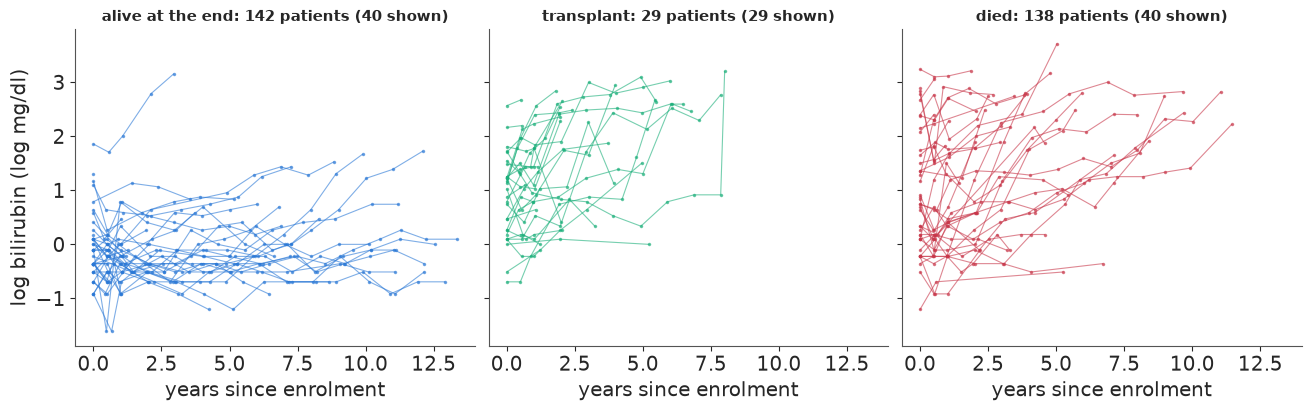

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, sharex=True)
for ax, (code, label, color) in zip(axes, [(0, "alive at the end", BLUE),
                                           (1, "transplant", AQUA), (2, "died", RED)]):
    group = pat.index[pat.status == code]
    for i in rng.choice(group, size=min(40, len(group)), replace=False):
        v = obs[obs.id == i]
        ax.plot(v.t, v.y, color=color, lw=0.8, alpha=0.6, marker=".", ms=3)
    ax.set_title(f"{label}: {len(group)} patients ({min(40, len(group))} shown)", fontsize=11)
    ax.set_xlabel("years since enrolment")
axes[0].set_ylabel("log bilirubin (log mg/dl)");

The picture that motivates everything. Patients who died (right) tend to start higher and to
climb; their lines stop early, because a dead patient has no more lab visits. Patients who
were alive at the end mostly have flat, low trajectories that run for ten years or more.
Transplanted patients look like the ones who died: transplant was given to the sickest.

### The average trajectory lies

The obvious summary of how bilirubin evolves is the mean of the measurements taken in each
year of follow-up. Watch what dropout does to it.

In [5]:
year = np.floor(t_obs).astype(int)
by_year = pd.DataFrame({"year": year, "y": y_obs, "id": obs.id}).groupby("year").agg(
    mean_log_bili=("y", "mean"), patients=("id", "nunique"))
by_year.T.round(2)

year,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
mean_log_bili,0.53,0.63,0.77,0.6,0.54,0.67,0.71,0.63,0.49,0.77,0.52,0.5,0.61,1.02,1.23
patients,309.00,206.00,191.00,155.0,124.00,116.00,100.00,74.00,55.00,39.00,24.00,20.0,13.00,6.00,2.00


The yearly mean rises during the first two years and then stops rising (it falls back and
fluctuates between 0.5 and 0.8 until the last handful of patients), while the number of patients measured drops from 309 to a
few dozen. Does bilirubin stop
rising after five years? No: the patients whose bilirubin rose are **no longer in the data**.
The later years are averages over the survivors, who were healthier to begin with. This is
**informative dropout**: whether a measurement exists depends on the value it would have had.
Any analysis of the longitudinal data alone has to worry about it, and any analysis of
survival that uses the measured values has to worry about the fact that they are noisy
snapshots. The joint model deals with both.

## 2 · Two tempting shortcuts

E06 used an accelerated-failure-time Weibull. Here the covariate changes over time, and the
natural formulation is **proportional hazards**: a baseline hazard $h_0(t)$ multiplied by
$\exp(\text{linear predictor})$. With a Weibull baseline of shape $k$,

$$ h_i(t) = k\,t^{k-1}\exp(\eta_i(t)), \qquad
   H_i(T) = \int_0^T h_i(t)\,dt, \qquad
   \log L_i = d_i \log h_i(T_i) - H_i(T_i), $$

where $d_i = 1$ for a death and 0 for censoring. The survival likelihood of E06 in hazard
form: an event contributes the density $h\,S$, a censored patient only $S = e^{-H}$. When
$\eta_i$ is constant, $H_i(T) = T^k e^{\eta_i}$.

All survival submodels in this notebook share the same priors: $k \sim$ LogNormal(0, 0.5)
(hazard shape near constant), intercept $\eta_0 \sim N(-3, 1.5)$ (a yearly death rate of
about 5% for a typical patient, give or take a factor of 20), and $N(0, 1)$ on the treatment
and age log hazard ratios and on $\alpha$, the log hazard ratio per unit of log bilirubin.

In [6]:
SURV_VARS = ["k", "eta0", "gamma_trt", "gamma_age", "alpha"]


def survival_priors():
    """Weibull shape, the time-constant part of the linear predictor, and alpha."""
    k = pm.LogNormal("k", 0, 0.5)
    eta0 = pm.Normal("eta0", -3, 1.5)
    g_trt = pm.Normal("gamma_trt", 0, 1)
    g_age = pm.Normal("gamma_age", 0, 1)
    alpha = pm.Normal("alpha", 0, 1)
    return k, eta0 + g_trt * trt + g_age * age, alpha


def fit(model, **kw):
    """One place for the sampler settings; every fit reports time and divergences."""
    start = time.perf_counter()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    print(f"{model.name}: {time.perf_counter() - start:.0f} s, "
          f"divergences = {int(idata.sample_stats['diverging'].sum())}")
    return idata

**Shortcut (a): baseline bilirubin only.** Put the log bilirubin measured at enrolment into
$\eta_i$ and ignore everything measured later.

**Shortcut (b): last value carried forward.** Use every measurement as a time-varying
covariate: between two visits, $\eta_i(t)$ uses the most recent observed value. The
follow-up of each patient is cut at her visit times into intervals $[t_j, t_{j+1})$, on each
of which the hazard is constant apart from the Weibull factor, so
$H_i = \sum_j e^{\eta_{ij}}\,(t_{j+1}^k - t_j^k)$ - the counting-process form of a Cox model
with time-varying covariates.

In [7]:
with pm.Model(name="baseline") as m_base:
    k, lin, alpha = survival_priors()
    eta = lin + alpha * pat.y0.to_numpy()
    pm.Potential("survival", pt.sum(event * (pt.log(k) + (k - 1) * np.log(T) + eta)
                                    - pt.exp(eta) * T**k))

seg_start = t_obs
seg_stop = obs.groupby("id").t.shift(-1).to_numpy()
seg_stop = np.where(np.isnan(seg_stop), T[pid], seg_stop)   # last interval ends at T_i
y_last = obs.groupby("id").y.last().to_numpy()              # value in force at T_i
assert (seg_stop > seg_start).all()

with pm.Model(name="locf") as m_locf:
    k, lin, alpha = survival_priors()
    eta_seg = lin[pid] + alpha * y_obs
    H = pt.sum(pt.exp(eta_seg) * (seg_stop**k - seg_start**k))
    pm.Potential("survival", pt.sum(event * (pt.log(k) + (k - 1) * np.log(T) + lin + alpha * y_last)) - H)

idata_base = fit(m_base)
idata_locf = fit(m_locf)

baseline: 2 s, divergences = 0


locf: 1 s, divergences = 0


In [8]:
def alpha_row(idata, prefix):
    post = az.extract(idata)
    a = post[f"{prefix}::alpha"].values
    kk = post[f"{prefix}::k"].values
    return {"alpha mean": a.mean(), "alpha sd": a.std(), "HR per doubling": np.mean(2**a),
            "Weibull shape k": kk.mean()}


pd.DataFrame({"(a) baseline value": alpha_row(idata_base, "baseline"),
              "(b) last value carried forward": alpha_row(idata_locf, "locf")}).T.round(2)

,alpha mean,alpha sd,HR per doubling,Weibull shape k
(a) baseline value,1.03,0.09,2.05,1.40
(b) last value carried forward,1.45,0.09,2.74,1.22


Both say bilirubin is a strong predictor, but they disagree on how strong, and they disagree
on the shape of the baseline hazard. With baseline bilirubin only, $k \approx 1.4$: the
hazard seems to **rise** with time since enrolment. That is not a property of time; it is the
bilirubin rise that the model cannot see, pushed into the baseline hazard. Both shortcuts
also mistreat the biomarker in opposite directions:

- (a) uses one noisy value for a quantity that drifts for ten years;
- (b) uses the latest noisy value, stale by up to a year or more, as if it were exact.
  Measurement error in a covariate attenuates its coefficient; but visits are also more
  frequent when patients are unwell, which pushes the other way. Which effect wins is an
  empirical question, and the shortcut gives no way to tell.

## 3 · The joint model

**Longitudinal submodel.** Each patient has a true log bilirubin trajectory $m_i(t)$, a line
with patient-specific intercept and slope, measured with Normal noise:

$$ y_{ij} = m_i(t_{ij}) + \varepsilon_{ij}, \quad \varepsilon_{ij} \sim N(0, \sigma), \qquad
   m_i(t) = (\beta_0 + b_{0i}) + (\beta_1 + \beta_{\text{trt}}\,\text{trt}_i + b_{1i})\,t, $$

$$ (b_{0i}, b_{1i}) \sim \text{MvNormal}(0, \Sigma), \qquad
   \Sigma = \text{diag}(\tau)\,\Omega\,\text{diag}(\tau), \quad \Omega \sim \text{LKJ}(2). $$

$\beta_{\text{trt}}$ lets D-penicillamine change the rate of progression. The correlation in
$\Omega$ says whether patients who start high also climb fast.

**Survival submodel.** The hazard depends on the **current true value**, not on the last
measurement:

$$ h_i(t) = k\,t^{k-1}\exp\big(\eta_0 + \gamma_{\text{trt}}\,\text{trt}_i
   + \gamma_{\text{age}}\,\text{age}_i + \alpha\,m_i(t)\big). $$

The random effects $b_i$ appear in both submodels: that is the whole trick. A patient who
died early "explains" some of the steepness of her slope, and a steep slope raises her
hazard. $\alpha$ is the log hazard ratio for a one-unit difference in *true* log bilirubin at
the same moment, so $2^\alpha$ is the hazard ratio per doubling of bilirubin.

### The cumulative hazard is an integral

$H_i(T_i) = \int_0^{T_i} k\,t^{k-1} e^{\eta_i + \alpha m_i(t)}\,dt$ has a closed form only
for $k = 1$ (the integral of an exponential of a line). In general we need quadrature, and
a naive Gauss-Legendre rule on $[0, T]$ suffers when $k < 1$ because $t^{k-1}$ is infinite at
0. The substitution $u = t^k$ (so $du = k\,t^{k-1}dt$) removes the singularity:

$$ H_i(T) = e^{\eta_i}\int_0^{T^k} \exp\big(\alpha\, m_i(u^{1/k})\big)\,du, $$

a smooth integrand on which 15 Gauss-Legendre nodes are plenty. One function serves NumPy
(checks, predictions) and PyTensor (the model), since both broadcast the same way.

In [9]:
GL_X, GL_W = np.polynomial.legendre.leggauss(15)   # nodes and weights on [-1, 1]


def cum_hazard(T, k, lin, alpha, a, s, xp=np):
    """H(T) for m(t) = a + s t; all array arguments broadcast; nodes go on a new last axis."""
    U = T**k
    u = U[..., None] / 2 * (GL_X + 1)                # nodes on [0, T^k]
    m = a[..., None] + s[..., None] * u ** (1 / k)   # biomarker at t = u^(1/k)
    return xp.exp(lin) * xp.sum(U[..., None] / 2 * GL_W * xp.exp(alpha * m), axis=-1)


def reference(T, k, a, s, alpha):
    """SciPy adaptive quadrature of the original integral."""
    return integrate.quad(lambda t: k * t ** (k - 1) * np.exp(alpha * (a + s * t)), 0, T)[0]


def naive_gl(T, k, a, s, alpha):
    """Gauss-Legendre directly on [0, T], without the change of variables."""
    t = T / 2 * (GL_X + 1)
    return np.sum(T / 2 * GL_W * k * t ** (k - 1) * np.exp(alpha * (a + s * t)))


rows = []
for k_, a_, s_, T_ in [(1.0, 0.5, 0.3, 10.0), (0.7, 1.0, -0.2, 12.0), (1.4, 2.0, 0.6, 14.0),
                       (1.1, -0.5, 0.2, 3.0), (0.5, 0.0, 0.3, 8.0)]:
    ref = reference(T_, k_, a_, s_, 1.3)
    rows.append({"k": k_, "a": a_, "s": s_, "T": T_, "SciPy quad": ref,
                 "GL, u = t^k": cum_hazard(np.array(T_), k_, 0.0, 1.3, np.array(a_), np.array(s_)),
                 "GL naive": naive_gl(T_, k_, a_, s_, 1.3),
                 "closed form (k = 1)": (np.exp(1.3 * a_) * (np.exp(1.3 * s_ * T_) - 1) / (1.3 * s_)
                                         if k_ == 1 else np.nan)})
quad_check = pd.DataFrame(rows)
quad_check["rel. error, u = t^k"] = (quad_check["GL, u = t^k"] / quad_check["SciPy quad"] - 1).abs()
quad_check["rel. error, naive"] = (quad_check["GL naive"] / quad_check["SciPy quad"] - 1).abs()
quad_check.style.format(precision=4).format(
    "{:.1e}", subset=["rel. error, u = t^k", "rel. error, naive"])

,k,a,s,T,SciPy quad,"GL, u = t^k",GL naive,closed form (k = 1),"rel. error, u = t^k","rel. error, naive"
0,1.0000,0.5000,0.3000,10.0000,237.7356,237.7356,237.7356,237.7356,6.7e-16,6.7e-16
1,0.7000,1.0000,-0.2000,12.0000,8.3682,8.3682,8.2614,nan,1.0e-06,1.3e-02
2,1.4000,2.0000,0.6000,14.0000,3688452.6488,3688452.6715,3688452.6782,nan,6.1e-09,8.0e-09
3,1.1000,-0.5000,0.2000,3.0000,2.6946,2.6946,2.6949,nan,3.3e-07,8.9e-05
4,0.5000,0.0000,0.3000,8.0000,12.8822,12.8822,12.8029,nan,3.3e-15,6.2e-03


With the substitution, 15 nodes match SciPy's adaptive quadrature to a relative error of
$10^{-6}$ or better, including a case where $H$ is $3.7 \times 10^6$ (a very steep
trajectory), and the $k = 1$ case agrees with the closed form to machine precision. The naive
rule is fine for $k \ge 1$ but off by 1.3% at $k = 0.7$ and 0.6% at $k = 0.5$: a bias that
would enter every likelihood and gradient evaluation whenever the sampler visits $k < 1$. The model is now a few lines. The survival part enters through
`pm.Potential`, because the log-likelihood is not a named distribution; the random effects
are written in one of three equivalent ways, compared in section 5.

In [10]:
LONG_VARS = ["beta0", "beta1", "beta_trt", "sigma", "chol_corr", "chol_stds"]
COORDS = {"patient": ids, "effect": ["intercept", "slope"], "obs": np.arange(len(obs))}


def longitudinal_part(param="hier"):
    """Mixed model for log bilirubin. Returns the intercepts and slopes of the latent m_i(t),
    stored as `coef` (patient, effect). `param` chooses how the random effects are written:
    "centred" b_i ~ MvNormal(0, Sigma), coef = mean + b_i
    "noncentred" z_i ~ Normal(0, 1), coef = mean + L z_i
    "hier" coef_i ~ MvNormal(mean_i, Sigma) (hierarchical centring: the means sit inside)"""
    beta0 = pm.Normal("beta0", 0, 1)
    beta1 = pm.Normal("beta1", 0, 0.25)
    beta_trt = pm.Normal("beta_trt", 0, 0.25)
    sigma = pm.HalfNormal("sigma", 0.5)
    chol, _, _ = pm.LKJCholeskyCov("chol", n=2, eta=2.0, compute_corr=True,
                                   sd_dist=pm.HalfNormal.dist([1.0, 0.25], shape=2))
    mean = pt.stack([pt.ones(len(ids)) * beta0, beta1 + beta_trt * trt], axis=1)   # (patient, 2)
    if param == "centred":
        b = pm.MvNormal("b", 0, chol=chol, dims=("patient", "effect"))
        coef = pm.Deterministic("coef", mean + b, dims=("patient", "effect"))
    elif param == "noncentred":
        z = pm.Normal("z", 0, 1, dims=("patient", "effect"))
        coef = pm.Deterministic("coef", mean + z @ chol.T, dims=("patient", "effect"))
    else:
        coef = pm.MvNormal("coef", mean, chol=chol, dims=("patient", "effect"))
    a_i, s_i = coef[:, 0], coef[:, 1]
    pm.Normal("y", a_i[pid] + s_i[pid] * t_obs, sigma, observed=y_obs, dims="obs")
    return a_i, s_i


def joint_model(param="hier", name="joint"):
    with pm.Model(coords=COORDS, name=name) as model:
        a_i, s_i = longitudinal_part(param)
        k, lin, alpha = survival_priors()
        log_h_T = pt.log(k) + (k - 1) * np.log(T) + lin + alpha * (a_i + s_i * T)
        H_T = cum_hazard(T, k, lin, alpha, a_i, s_i, xp=pt)
        pm.Potential("survival", pt.sum(event * log_h_T - H_T))
    return model


m_joint = joint_model()
print(f"{len(m_joint.free_RVs)} free variables, "
      f"{sum(v.size for v in m_joint.initial_point().values())} unconstrained dimensions")

11 free variables, 630 unconstrained dimensions


## 4 · Prior predictive check

`pm.Potential` terms are ignored by prior predictive sampling (PyMC warns about it), so we
draw the parameters from the prior and compute what they imply ourselves: latent bilirubin
trajectories of simulated patients, and the 5-year survival of a typical patient (population
mean trajectory, age 50, placebo).

/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_25357/529932774.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)


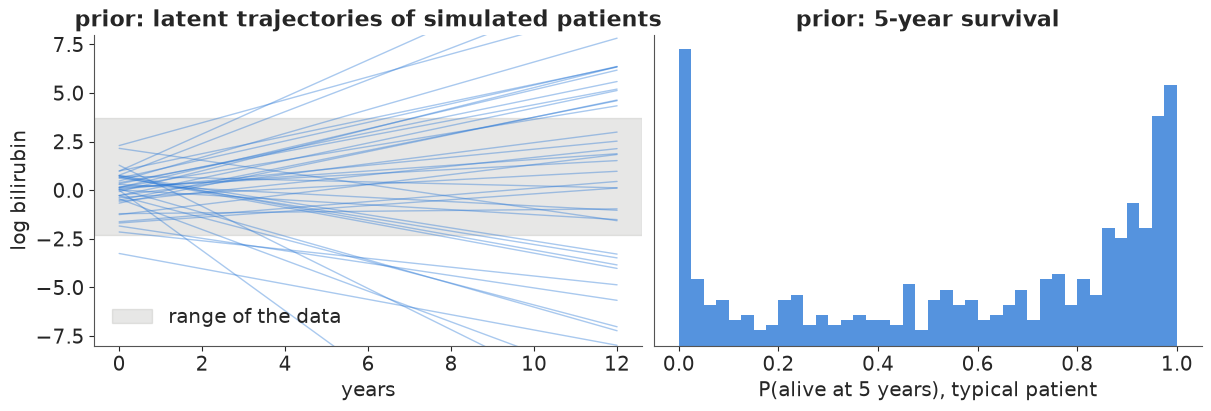

In [11]:
with m_joint:
    prior = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)
pr = az.extract(prior, group="prior")
v = lambda name: pr[f"joint::{name}"].values  # noqa: E731

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tgrid = np.linspace(0, 12, 50)
coef_prior = v("coef")                           # (patient, effect, sample)
for j in range(40):
    axes[0].plot(tgrid, coef_prior[0, 0, j] + coef_prior[0, 1, j] * tgrid, color=BLUE, alpha=0.4, lw=1)
axes[0].axhspan(y_obs.min(), y_obs.max(), color=GREY, alpha=0.2, label="range of the data")
axes[0].set(xlabel="years", ylabel="log bilirubin", ylim=(-8, 8),
            title="prior: latent trajectories of simulated patients")
axes[0].legend(loc="lower left")

S5 = np.exp(-np.array([cum_hazard(np.array(5.0), v("k")[j], v("eta0")[j], v("alpha")[j],
                                   np.array(v("beta0")[j]), np.array(v("beta1")[j])) for j in range(500)]))
axes[1].hist(S5, bins=40, color=BLUE, alpha=0.8)
axes[1].set(xlabel="P(alive at 5 years), typical patient", yticks=[],
            title="prior: 5-year survival");

Wide, but on the right scale. Most simulated trajectories stay within a few units of the
observed range over a decade; the steepest ones leave it, which is acceptable for a prior
that should not rule out fast progression. The implied 5-year survival of a typical patient
covers the whole interval, with a lump near 1 and a smaller spike near 0 (prior draws that
combine a high baseline hazard with a large $\alpha$). Nothing here constrains the answer:
with 138 deaths and 1907 measurements the data will do the work.

## 5 · Fitting: three ways to write the same random effects

E02 taught the non-centred parameterisation as the cure for divergences in hierarchical
models. That cure is for groups with **little data**, where each group effect is mostly prior
and the funnel between the group sd and the effects is sharp. Here most patients have several
measurements, so each patient's intercept and slope are pinned down by her own data. That is
the situation in which the *centred* form has the better geometry - but there are two ways to
centre:

- **centred**: $b_i \sim \text{MvNormal}(0, \Sigma)$ and $m_i(t) = (\beta_0 + b_{0i}) + \ldots$ -
  the textbook way to write a mixed model;
- **non-centred**: $z_i \sim N(0, I)$, $b_i = L z_i$ with $LL^\top = \Sigma$;
- **hierarchically centred**: the patient's coefficients themselves are the random variable,
  $(a_i, s_i) \sim \text{MvNormal}\big((\beta_0,\ \beta_1 + \beta_{\text{trt}}\,\text{trt}_i), \Sigma\big)$.

All three define the same model. Fit each once and compare sampling efficiency.

In [12]:
KEEP = LONG_VARS + SURV_VARS
fits = {}
for param in ["centred", "noncentred", "hier"]:
    model = m_joint if param == "hier" else joint_model(param, name=param)
    prefix = model.name
    extra = ["coef"] if param == "hier" else []
    start = time.perf_counter()
    idata = fit(model, var_names=[f"{prefix}::{v}" for v in KEEP + extra])
    ess = az.ess(idata, var_names=[f"{prefix}::{v}" for v in ["beta0", "beta1", "chol_stds", "alpha", "k"]])
    rhat = az.rhat(idata, var_names=[f"{prefix}::{v}" for v in ["beta0", "beta1", "chol_stds", "alpha", "k"]])
    fits[param] = idata
    row = {"seconds": time.perf_counter() - start,
           "divergences": int(idata.sample_stats["diverging"].sum()),
           "max r_hat": max(float(rhat[n].max()) for n in rhat.data_vars)}
    for n in ess.data_vars:
        vals = np.atleast_1d(ess[n].values)
        for i, val in enumerate(vals):
            label = n.split("::")[1] + (f"[{i}]" if len(vals) > 1 else "")
            row[f"ESS {label}"] = float(val)
    fits[param + "_row"] = row
param_table = pd.DataFrame({p: fits[p + "_row"] for p in ["centred", "noncentred", "hier"]}).T
param_table.round(3)

centred: 10 s, divergences = 0


noncentred: 27 s, divergences = 0


joint: 10 s, divergences = 0


,seconds,divergences,max r_hat,ESS beta0,ESS beta1,ESS chol_stds[0],ESS chol_stds[1],ESS alpha,ESS k
centred,10.275,0.0,1.020,232.247,371.685,5845.369,1725.755,3672.019,5995.991
noncentred,26.595,0.0,1.074,203.871,155.831,462.117,400.350,78.620,38.065
hier,9.949,0.0,1.001,6776.898,4427.386,6827.837,2150.083,3879.071,5610.317


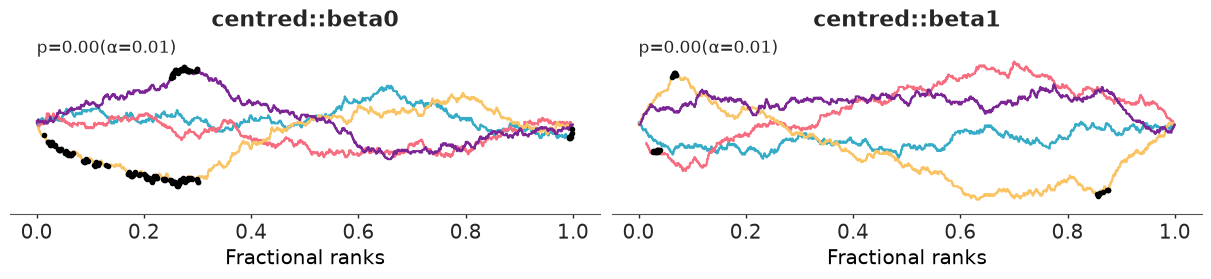

In [13]:
az.plot_rank(fits["centred"], var_names=["centred::beta0", "centred::beta1"]);

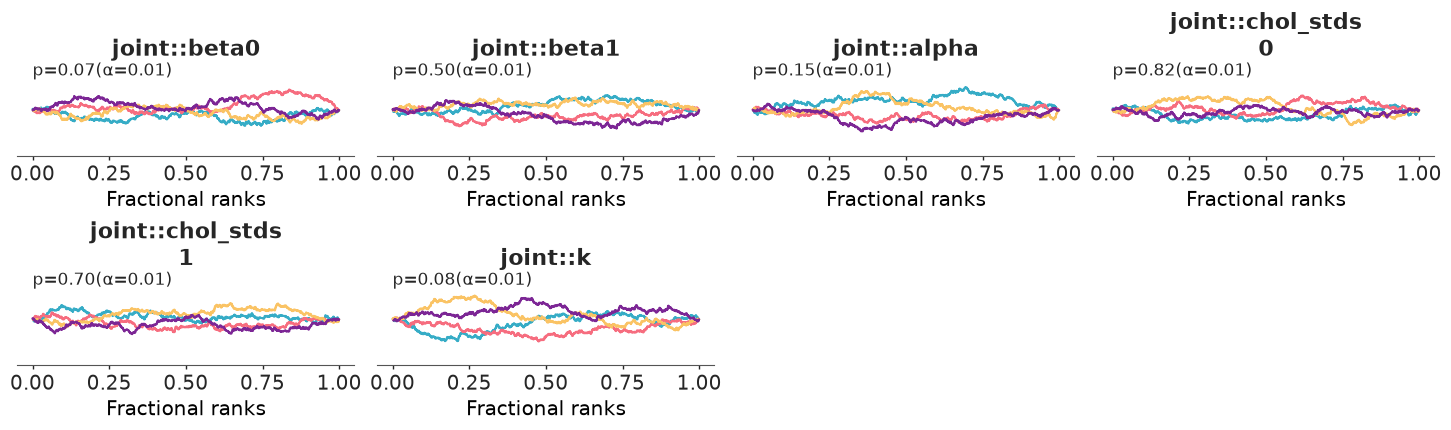

In [14]:
idata_joint = fits["hier"]
fits = None
az.plot_rank(idata_joint, var_names=["joint::beta0", "joint::beta1", "joint::alpha", "joint::chol_stds", "joint::k"]);

All three agree on the posterior (compare the means in the summary below with a centred or
non-centred fit if you like) and none of them reports a divergence - but they are very
different samplers of it:

- **Centred** mixes the random effects well but the population means badly: ESS of about
  200-400 for $\beta_0$ and $\beta_1$ out of 4000 draws, and the rank plots above flag both
  (chains spend long stretches in the top or bottom of the distribution). The reason is a
  ridge in the posterior: $\beta_0 + b_{0i}$ is what the data determine, so shifting
  $\beta_0$ up and all 309 $b_{0i}$ down leaves the likelihood unchanged, and only the weak
  pull of the zero-mean prior on $b_i$ resolves it.
- **Non-centred** is the slowest, has the lowest ESS for the random-effect sds, and in this
  run its `r_hat` of 1.07 and tiny ESS for $\alpha$ and $k$ say it has not converged at all.
  (With other seeds we tried, $\alpha$ and $k$ came out fine but the sds were always the
  worst of the three: the failure is seed-dependent, its direction is not.) When every group
  has informative data, non-centring *creates* the dependence between $z_i$ and the sds that
  it was meant to remove.
- **Hierarchically centred** removes the ridge: the patient coefficients are centred on the
  population means, so the means are informed directly by 309 noisy "observations" of
  themselves. ESS jumps to several thousand for every parameter, `r_hat` is 1.00, the rank
  plots are flat, and it costs no more time than the centred fit.

The lesson generalises: which parameterisation samples well depends on how much data each
group has, and "non-centre everything" is not a safe default. The rest of the notebook uses
the hierarchically centred fit.

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)  # r_hat of the constant diagonal of chol_corr
    joint_summary = az.summary(idata_joint, var_names=[f"joint::{v}" for v in LONG_VARS + SURV_VARS],
                               ci_kind="hdi", ci_prob=0.94, round_to=3)
joint_summary

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
joint::beta0,0.494,0.060,0.387,0.610,6776.898,3468.389,1.000,0.001,0.001
joint::beta1,0.183,0.018,0.150,0.218,4427.386,3504.702,1.001,0.000,0.000
joint::beta_trt,0.004,0.025,-0.043,0.052,5239.568,3100.851,1.001,0.000,0.000
joint::sigma,0.346,0.007,0.333,0.358,3079.651,2760.966,1.001,0.000,0.000
"joint::chol_corr[0, 0]",1.000,0.000,1.000,1.000,4000.000,4000.000,NaN,0.000,NaN
"joint::chol_corr[0, 1]",0.422,0.073,0.281,0.553,3066.393,3323.203,1.001,0.001,0.001
"joint::chol_corr[1, 0]",0.422,0.073,0.281,0.553,3066.393,3323.203,1.001,0.001,0.001
"joint::chol_corr[1, 1]",1.000,0.000,1.000,1.000,3916.746,4000.000,1.001,0.000,0.000
joint::chol_stds[0],1.007,0.043,0.928,1.091,6827.837,3544.065,1.001,0.001,0.001
joint::chol_stds[1],0.183,0.013,0.160,0.207,2150.083,2860.691,1.000,0.000,0.000


Reading the table:

- **Longitudinal:** typical log bilirubin at enrolment is about 0.5 (1.6 mg/dl), rising by
  about 0.18 per year on average (bilirubin doubles every ~4 years). Patients differ hugely in
  level (sd about 1 on the log scale) and substantially in slope (sd about 0.18/year), and the
  two are positively correlated (about 0.4): those who start high also climb faster.
  Measurement noise $\sigma \approx 0.35$ is a factor of $e^{0.35} \approx 1.4$ - a single
  bilirubin value is a rough snapshot.
- **Survival:** $\alpha \approx 1.33$, a hazard ratio of about $2^{1.33} \approx 2.5$ per
  doubling of the *true* current bilirubin; each decade of age multiplies the hazard by about
  $e^{0.63} \approx 1.9$. The Weibull shape is now close to 1 (interval 0.93 to 1.26): once
  the rising bilirubin is in the model, the baseline hazard is roughly constant in time.

## 6 · What the shortcuts got wrong

One more comparison completes the set: the **two-stage** approach. Fit the longitudinal
mixed model alone, take each patient's posterior mean trajectory, and plug it into the
survival model as if it were known. It uses the right covariate (the smoothed trajectory),
but it ignores the uncertainty in each trajectory and the information that survival carries
about it.

In [16]:
with pm.Model(coords=COORDS, name="lmm") as m_lmm:
    longitudinal_part()
idata_lmm = fit(m_lmm, var_names=[f"lmm::{v}" for v in LONG_VARS + ["coef"]])

a_hat, s_hat = idata_lmm.posterior["lmm::coef"].mean(("chain", "draw")).values.T
with pm.Model(name="two_stage") as m_two:
    k, lin, alpha = survival_priors()
    log_h_T = pt.log(k) + (k - 1) * np.log(T) + lin + alpha * (a_hat + s_hat * T)
    pm.Potential("survival", pt.sum(event * log_h_T - cum_hazard(T, k, lin, alpha, a_hat, s_hat, xp=pt)))
idata_two = fit(m_two)

lmm: 4 s, divergences = 0


two_stage: 3 s, divergences = 0


In [17]:
comparison = pd.DataFrame({
    "(a) baseline value": alpha_row(idata_base, "baseline"),
    "(b) last value carried forward": alpha_row(idata_locf, "locf"),
    "(c) two-stage plug-in": alpha_row(idata_two, "two_stage"),
    "joint model": alpha_row(idata_joint, "joint"),
}).T
comparison.round(3)

,alpha mean,alpha sd,HR per doubling,Weibull shape k
(a) baseline value,1.033,0.086,2.050,1.402
(b) last value carried forward,1.450,0.095,2.739,1.219
(c) two-stage plug-in,1.238,0.085,2.363,1.079
joint model,1.333,0.101,2.526,1.093


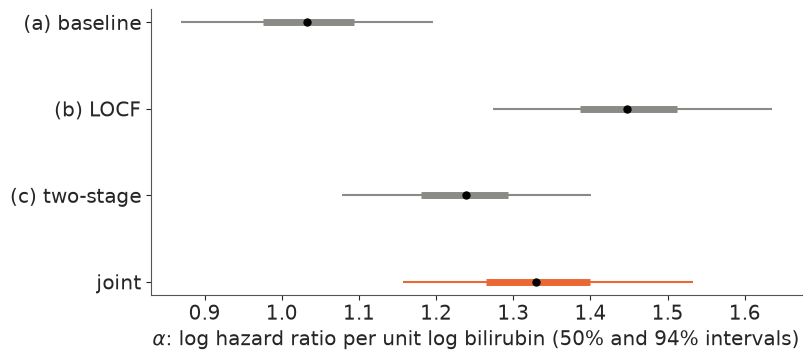

In [18]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for i, (label, idata, prefix) in enumerate([("(a) baseline", idata_base, "baseline"),
                                            ("(b) LOCF", idata_locf, "locf"),
                                            ("(c) two-stage", idata_two, "two_stage"),
                                            ("joint", idata_joint, "joint")]):
    a = az.extract(idata, var_names=f"{prefix}::alpha").values
    lo, q25, med, q75, hi = np.quantile(a, [0.03, 0.25, 0.5, 0.75, 0.97])
    color = ORANGE if label == "joint" else GREY
    ax.hlines(i, lo, hi, color=color, lw=1.5)
    ax.hlines(i, q25, q75, color=color, lw=5)
    ax.plot(med, i, "o", color="k", ms=5)
ax.set(yticks=range(4), yticklabels=["(a) baseline", "(b) LOCF", "(c) two-stage", "joint"],
       xlabel=r"$\alpha$: log hazard ratio per unit log bilirubin (50% and 94% intervals)")
ax.invert_yaxis();

Four answers to the same question:

- **(a) Baseline value**, $\alpha \approx 1.0$: the smallest. A single value measured at
  enrolment is a noisy and increasingly out-of-date proxy for the current state, so its
  coefficient is attenuated, and the hazard shape $k$ absorbs the rest.
- **(c) Two-stage**, $\alpha \approx 1.24$: smaller than the joint estimate *and* with a
  narrower interval. Posterior-mean trajectories are shrunk towards the population mean -
  most strongly for patients with few measurements, who are disproportionately the ones who
  died early - and treating them as exact hides the uncertainty. This is the textbook
  behaviour of plug-in estimates: attenuated and over-confident.
- **Joint**, $\alpha \approx 1.34$: uses every measurement, propagates the uncertainty of
  each trajectory, and lets survival inform the trajectories of patients with few visits.
- **(b) LOCF**, $\alpha \approx 1.45$: the largest. Classical measurement error would
  *attenuate* it, so noise is not the whole story. Two candidate explanations, both about
  what the joint model assumes rather than virtues of LOCF: a straight-line trajectory may
  miss a terminal acceleration of bilirubin that the last measurement captures, and visit
  timing may depend on health (an unscheduled visit when a patient deteriorates puts a
  recent, high value in force just before death). Section 7 checks the first; the data at
  hand cannot settle the second.

### The dropout bias in the longitudinal model

The mixed model fitted alone is the first stage of (c). How different is its estimate of
the average rate of progression from the joint model's?

mean slope beta1, mixed model alone: 0.177 (94%: 0.143 to 0.212)
mean slope beta1, joint model:       0.183 (94%: 0.150 to 0.218)


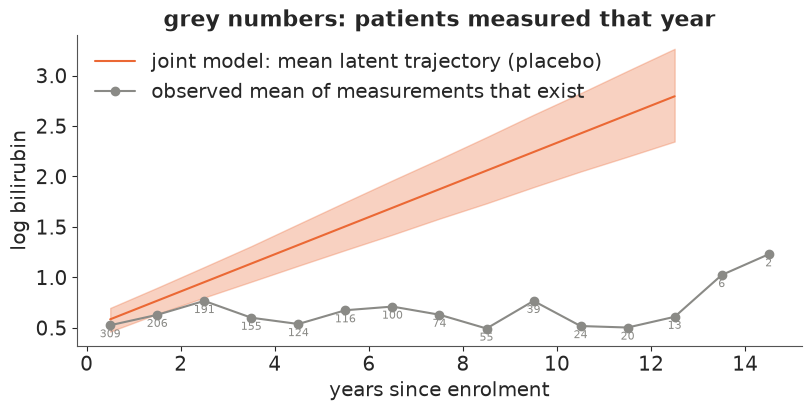

In [19]:
def q(idata, name):
    x = az.extract(idata, var_names=name).values
    return f"{x.mean():.3f} (94%: {np.quantile(x, 0.03):.3f} to {np.quantile(x, 0.97):.3f})"


print("mean slope beta1, mixed model alone:", q(idata_lmm, "lmm::beta1"))
print("mean slope beta1, joint model:      ", q(idata_joint, "joint::beta1"))

post_j = az.extract(idata_joint, num_samples=1000, random_seed=RANDOM_SEED)
tg = np.arange(0, 13) + 0.5                      # middle of each year
mean_traj = post_j["joint::beta0"].values[:, None] + post_j["joint::beta1"].values[:, None] * tg
fig, ax = plt.subplots(figsize=(8, 4))
lo, hi = np.quantile(mean_traj, [0.03, 0.97], axis=0)
ax.fill_between(tg, lo, hi, color=ORANGE, alpha=0.3)
ax.plot(tg, mean_traj.mean(0), color=ORANGE, label="joint model: mean latent trajectory (placebo)")
ax.plot(by_year.index + 0.5, by_year.mean_log_bili, "o-", color=GREY,
        label="observed mean of measurements that exist")
for x, n in zip(by_year.index, by_year.patients):
    ax.annotate(str(n), (x + 0.5, by_year.mean_log_bili[x] - 0.12), ha="center", fontsize=8, color=GREY)
ax.set(xlabel="years since enrolment", ylabel="log bilirubin",
       title="grey numbers: patients measured that year")
ax.legend(loc="upper left");

The model's mean trajectory - what the average enrolled patient's bilirubin would do if
nobody died, extrapolating the straight lines - keeps rising at about 0.18 per year for the
whole decade. The naive yearly average stops rising after year two and hovers between 0.5
and 0.8 (the last two points rest on 6 and 2 patients), because it averages over a shrinking, healthier group of survivors. The mixed model fitted alone already corrects most of
that: it models *each patient's* trajectory, and the random slopes carry the information that
early dropouts were on steep paths. Its mean slope is only slightly lower than the joint
model's, well within the posterior uncertainty. The remaining difference is the part of the
dropout that depends on the unobserved future of a trajectory, which only a model of the
dropout process itself (the survival submodel) can use. In this data set, the biggest
payoff of the joint model is on the survival side, not the longitudinal side.

## 7 · Model checks

### Is a straight line enough?

If bilirubin accelerates before death, the linear trajectory will sit **below** the
measurements taken in the last year or two of patients who died. Plot the residuals
(measurement minus posterior mean of $m_i(t)$) against time remaining until death.

mean residual by years before death (0-1, 1-2, 2-3): [ 0.09 -0.09 -0.03]


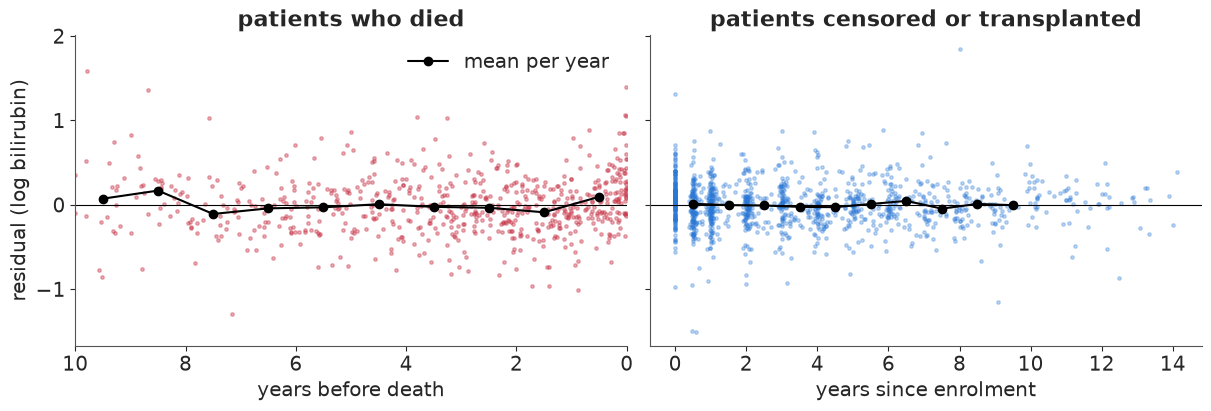

In [20]:
coef_mean = idata_joint.posterior["joint::coef"].mean(("chain", "draw")).values
m_fit = coef_mean[pid, 0] + coef_mean[pid, 1] * t_obs
resid = y_obs - m_fit
died_obs = event[pid] == 1
to_death = (T[pid] - t_obs)[died_obs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].scatter(to_death, resid[died_obs], s=6, color=RED, alpha=0.4)
bins = np.arange(0, 11, 1.0)
idx = np.digitize(to_death, bins) - 1
means = [resid[died_obs][idx == j].mean() for j in range(len(bins) - 1)]
axes[0].plot(bins[:-1] + 0.5, means, "ko-", label="mean per year")
axes[0].axhline(0, color="k", lw=0.8)
print("mean residual by years before death (0-1, 1-2, 2-3):", np.round(means[:3], 2))
axes[0].set(xlabel="years before death", ylabel="residual (log bilirubin)",
            title="patients who died", xlim=(10, 0))
axes[0].legend()
since = t_obs[~died_obs]
axes[1].scatter(since, resid[~died_obs], s=6, color=BLUE, alpha=0.3)
idx = np.digitize(since, bins) - 1
means_c = [resid[~died_obs][idx == j].mean() for j in range(len(bins) - 1)]
axes[1].plot(bins[:-1] + 0.5, means_c, "ko-")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(xlabel="years since enrolment", title="patients censored or transplanted");

A weaker signal than one might expect. On average the residuals of patients who died are
close to zero at every distance from death; only in the final year is the mean residual
positive, by about 0.1 on the log scale (bilirubin about 10% above the fitted line), with
a slightly negative year before it - the mild signature of a curve forced into a straight
line. The straight line misses a little of the terminal rise, which pushes in the direction
of the LOCF estimate, but 0.1 on the log scale times $\alpha \approx 1.3$ is a hazard
difference of about 14% in the last year only: probably not enough to explain the whole gap
between the two $\alpha$ estimates. For the other patients the residuals are centred on zero
throughout. Averages hide individuals, though, and patient 38 in section 9 is one whose
trajectory is clearly not a line. The fix is a more flexible trajectory (a spline basis or
a random walk per patient - see "Try it yourself"); the machinery of the joint model does
not change, only $m_i(t)$ and the quadrature integrand.

### Does the model reproduce the survival curve?

For each posterior draw, every patient has a survival curve $S_i(t) = e^{-H_i(t)}$ from her
own trajectory. Their average over patients is the model's marginal survival curve, which we
compare with the Kaplan-Meier estimate (E06) of the same patients, transplants censored.

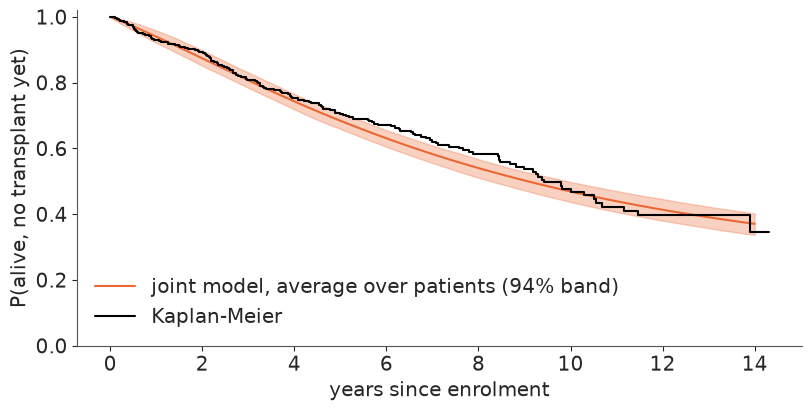

In [21]:
def kaplan_meier(time, event):
    time, event = np.asarray(time, dtype=float), np.asarray(event, dtype=bool)
    t_event = np.unique(time[event])
    at_risk = np.array([(time >= t).sum() for t in t_event])
    deaths = np.array([((time == t) & event).sum() for t in t_event])
    surv = np.cumprod(1 - deaths / at_risk)
    return np.r_[0, t_event, time.max()], np.r_[1, surv, surv[-1]]


post_s = az.extract(idata_joint, num_samples=200, random_seed=RANDOM_SEED)
grid = np.linspace(0.01, 14, 60)
marg = []
for j in range(200):
    g = lambda n: float(post_s[f"joint::{n}"].values[j])  # noqa: E731
    a, s = post_s["joint::coef"].values[:, :, j].T
    lin = g("eta0") + g("gamma_trt") * trt + g("gamma_age") * age
    H = cum_hazard(grid[None, :], g("k"), lin[:, None], g("alpha"), a[:, None], s[:, None])
    marg.append(np.exp(-H).mean(axis=0))
marg = np.array(marg)

km_t, km_s = kaplan_meier(T, event)
fig, ax = plt.subplots(figsize=(8, 4))
lo, hi = np.quantile(marg, [0.03, 0.97], axis=0)
ax.fill_between(grid, lo, hi, color=ORANGE, alpha=0.3)
ax.plot(grid, marg.mean(0), color=ORANGE, label="joint model, average over patients (94% band)")
ax.step(km_t, km_s, where="post", color="k", lw=1.5, label="Kaplan-Meier")
ax.set(xlabel="years since enrolment", ylabel="P(alive, no transplant yet)", ylim=(0, 1.02))
ax.legend();

The model's marginal survival follows the Kaplan-Meier curve over the first four years and
the last four, but runs slightly **below** it between about years 5 and 9, where the KM steps
sit at or just above the upper edge of the 94% band: the model is a little too pessimistic
in mid follow-up. One plausible cause is visible in the construction: each patient's curve
extrapolates her straight-line trajectory, and bilirubin keeps rising in the model for as
long as we extend the line, whereas many real trajectories flatten. It is a modest misfit,
worth remembering when we check the individual predictions below. (The comparison has a
caveat: the model curve follows every patient to 14 years whether or not she was observed
that long, while KM uses observed time only. With mostly administrative censoring - patients
enrolled later were followed for less time - the two estimate the same curve.)

## 8 · The treatment

D-penicillamine enters twice: through the bilirubin slope ($\beta_{\text{trt}}$) and directly
on the hazard at a given bilirubin level ($\gamma_{\text{trt}}$).

In [22]:
post_all = az.extract(idata_joint)
hr_direct = np.exp(post_all["joint::gamma_trt"].values)
slope_trt = post_all["joint::beta_trt"].values
print(f"direct hazard ratio exp(gamma_trt): median {np.median(hr_direct):.2f}, "
      f"94% interval {np.quantile(hr_direct, [0.03, 0.97]).round(2)}, P(HR < 1) = {(hr_direct < 1).mean():.2f}")
print(f"effect on the bilirubin slope (per year): median {np.median(slope_trt):.3f}, "
      f"94% interval {np.quantile(slope_trt, [0.03, 0.97]).round(3)}")
# total effect after 5 years: direct + via the slope difference accumulated over 5 years
hr_5y = np.exp(post_all["joint::gamma_trt"].values + post_all["joint::alpha"].values * slope_trt * 5)
print(f"total hazard ratio at year 5: median {np.median(hr_5y):.2f}, "
      f"94% interval {np.quantile(hr_5y, [0.03, 0.97]).round(2)}")

direct hazard ratio exp(gamma_trt): median 0.96, 94% interval [0.68 1.36], P(HR < 1) = 0.58
effect on the bilirubin slope (per year): median 0.004, 94% interval [-0.042  0.052]
total hazard ratio at year 5: median 0.99, 94% interval [0.63 1.53]


Famously, nothing. The trial's original conclusion - D-penicillamine does not slow the
disease or prolong survival - holds in every part of the model: the effect on the rate of
bilirubin rise is centred on zero with an interval of a few hundredths per year either way,
and the hazard ratios are centred near 1: 0.68 to 1.36 for the direct effect, 0.63 to 1.53
for the total effect at 5 years (wider, because it adds the uncertain slope effect times
$\alpha$ times 5 years). The posterior does not *prove* no effect, but it rules out halving
or doubling the hazard. Randomisation makes these comparisons fair; the joint model makes
the effect on progression estimable without the dropout bias.

## 9 · Dynamic prediction for new patients

This is what joint models are used for in the clinic. A patient has had $n$ visits up to
time $s$ and is alive. What is her probability of surviving another $\Delta t$ years, and how
does it change as new measurements arrive? The quantity is

$$ P(T_i > s + \Delta t \mid T_i > s, y_i(t \le s))
   = \int \frac{S_i(s + \Delta t \mid b)}{S_i(s \mid b)}\, p(b \mid T_i > s, y_i(t\le s))\,db. $$

For each posterior draw of the population parameters, the random effects of a *new*
patient are sampled in two steps. The longitudinal part is linear-Gaussian, so
$p(b \mid y_i(t\le s))$ is an exact bivariate Normal (the conjugate update of the prior
$N(0, \Sigma)$ with regression design $[1, t]$). Conditioning on survival to $s$ multiplies it
by $S_i(s \mid b)$, which we apply as an importance weight. The two combine into a ratio of
plain averages:

$$ P(\ldots) \approx \frac{\tfrac1M\sum_m S_i(s + \Delta t \mid b_m)}{\tfrac1M\sum_m S_i(s \mid b_m)},
   \qquad b_m \sim p(b \mid y_i(t \le s)). $$

Repeating this over posterior draws of the parameters gives a band that carries both the
patient-level and the population-level uncertainty. The three held-out patients were never
seen by the model.

In [23]:
PRED_DRAWS = az.extract(idata_joint, num_samples=300, random_seed=RANDOM_SEED)
PRED = {n: PRED_DRAWS[f"joint::{n}"].values
        for n in ["beta0", "beta1", "beta_trt", "sigma", "k", "eta0", "gamma_trt", "gamma_age", "alpha"]}
PRED["sd"] = PRED_DRAWS["joint::chol_stds"].values.T                     # (draw, 2)
PRED["corr"] = PRED_DRAWS["joint::chol_corr"].values.transpose(2, 0, 1)  # (draw, 2, 2)


def dynamic_prediction(t, y, trt_i, age_i, s_land, horizon, M=200, seed=0):
    """Conditional survival on `horizon` (> s_land) and the latent trajectory on [0, s_land],
    one row per posterior draw, given measurements (t, y) with t <= s_land."""
    rng_ = np.random.default_rng(seed)
    Z = np.c_[np.ones_like(t), t]
    t_line = np.linspace(0, s_land, 30)
    surv, traj = [], []
    for j in range(len(PRED["k"])):
        g = {n: PRED[n][j] for n in PRED}
        Sigma = np.outer(g["sd"], g["sd"]) * g["corr"]
        slope = g["beta1"] + g["beta_trt"] * trt_i
        resid = y - (g["beta0"] + slope * t)
        cov = np.linalg.inv(np.linalg.inv(Sigma) + Z.T @ Z / g["sigma"] ** 2)
        mean = cov @ Z.T @ resid / g["sigma"] ** 2
        b = rng_.multivariate_normal(mean, cov, size=M)
        a, s = g["beta0"] + b[:, 0], slope + b[:, 1]
        lin = g["eta0"] + g["gamma_trt"] * trt_i + g["gamma_age"] * age_i
        H_s = cum_hazard(np.array(s_land), g["k"], lin, g["alpha"], a, s)             # (M,)
        H_h = cum_hazard(horizon[None, :], g["k"], lin, g["alpha"], a[:, None], s[:, None])  # (M, G)
        w = np.exp(-H_s)
        surv.append(np.exp(-H_h).mean(0) / w.mean())
        traj.append((w[:, None] * (a[:, None] + s[:, None] * t_line)).sum(0) / w.sum())
    return np.array(surv), t_line, np.array(traj)

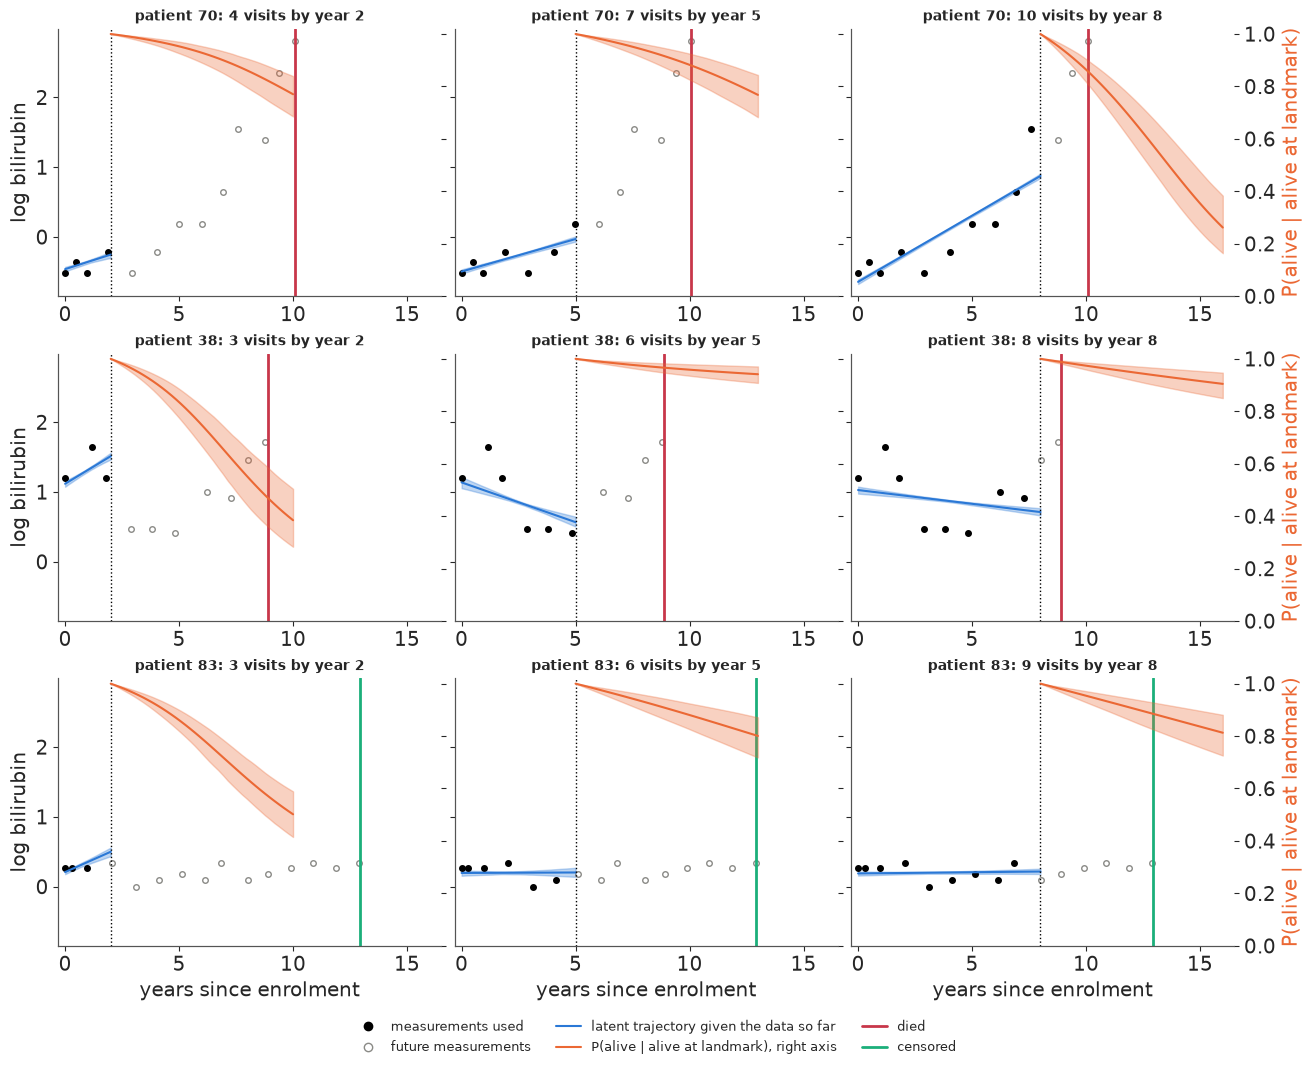

In [24]:
LANDMARKS = [2.0, 5.0, 8.0]
fig, axes = plt.subplots(len(HOLDOUT), len(LANDMARKS), figsize=(13, 10), sharey=True)
summary_rows = []
for r, i in enumerate(HOLDOUT):
    v_i = visits[visits.id == i].sort_values("day")
    p_i = patients.loc[i]
    for c, s_land in enumerate(LANDMARKS):
        ax = axes[r, c]
        seen = v_i.t <= s_land
        horizon = np.linspace(s_land, s_land + 8, 40)
        S, t_line, traj = dynamic_prediction(v_i.t[seen].to_numpy(), v_i.y[seen].to_numpy(), p_i.trt,
                                             (p_i.age - 50) / 10, s_land, horizon, seed=r * 10 + c)
        ax.plot(v_i.t[seen], v_i.y[seen], "o", color="k", ms=4, label="measurements used")
        ax.plot(v_i.t[~seen], v_i.y[~seen], "o", mfc="none", color=GREY, ms=4, label="future measurements")
        lo, hi = np.quantile(traj, [0.03, 0.97], axis=0)
        ax.fill_between(t_line, lo, hi, color=BLUE, alpha=0.3)
        ax.plot(t_line, traj.mean(0), color=BLUE)
        ax.axvline(s_land, color="k", ls=":", lw=1)
        outcome = {0: ("censored", AQUA), 1: ("transplant", AQUA), 2: ("died", RED)}[p_i.status]
        ax.axvline(p_i["T"], color=outcome[1], lw=2, label=outcome[0])
        ax2 = ax.twinx()
        lo, hi = np.quantile(S, [0.03, 0.97], axis=0)
        ax2.fill_between(horizon, lo, hi, color=ORANGE, alpha=0.3)
        ax2.plot(horizon, S.mean(0), color=ORANGE)
        ax2.set_ylim(0, 1.02)
        if c < len(LANDMARKS) - 1:
            ax2.set_yticklabels([])
        else:
            ax2.set_ylabel("P(alive | alive at landmark)", color=ORANGE)
        ax.set_title(f"patient {i}: {seen.sum()} visits by year {s_land:.0f}", fontsize=10)
        ax.set_xlim(-0.3, 16.5)
        p3 = S[:, np.searchsorted(horizon, s_land + 3)]
        summary_rows.append({"patient": i, "landmark (years)": s_land, "visits used": int(seen.sum()),
                             "P(alive 3 years later)": p3.mean(),
                             "94% lower": np.quantile(p3, 0.03), "94% upper": np.quantile(p3, 0.97),
                             "outcome": f"{outcome[0]} at {p_i['T']:.1f} y"})
    axes[r, 0].set_ylabel("log bilirubin")
handles = [plt.Line2D([], [], color="k", marker="o", ls="", label="measurements used"),
           plt.Line2D([], [], color=GREY, marker="o", mfc="none", ls="", label="future measurements"),
           plt.Line2D([], [], color=BLUE, label="latent trajectory given the data so far"),
           plt.Line2D([], [], color=ORANGE, label="P(alive | alive at landmark), right axis"),
           plt.Line2D([], [], color=RED, lw=2, label="died"),
           plt.Line2D([], [], color=AQUA, lw=2, label="censored")]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06), fontsize=9)
for ax in axes[-1]:
    ax.set_xlabel("years since enrolment");

In [25]:
pd.DataFrame(summary_rows).round(2)

,patient,landmark (years),visits used,P(alive 3 years later),94% lower,94% upper,outcome
0,70,2.0,4,0.95,0.92,0.97,died at 10.1 y
1,70,5.0,7,0.94,0.90,0.96,died at 10.1 y
2,70,8.0,10,0.77,0.70,0.83,died at 10.1 y
3,38,2.0,3,0.83,0.77,0.88,died at 8.9 y
4,38,5.0,6,0.97,0.96,0.99,died at 8.9 y
5,38,8.0,8,0.96,0.94,0.98,died at 8.9 y
6,83,2.0,3,0.86,0.81,0.90,censored at 12.9 y
7,83,5.0,6,0.93,0.89,0.96,censored at 12.9 y
8,83,8.0,9,0.93,0.89,0.96,censored at 12.9 y


Blue: the patient's latent trajectory as estimated from the measurements available at the
landmark (dotted line); orange: her conditional survival curve from the landmark on;
vertical line: what actually happened.

- **Patient 70** started with low bilirubin and a flat line. At year 2 the prediction is
  reassuring (3-year survival about 0.95). At year 5 the line tilts gently upwards and the
  forecast barely moves; by year 8, with a clearly rising slope, it has dropped to about
  0.77. She died at 10.1 years. This is the
  point of dynamic prediction: the forecast deteriorates with the measurements, before the
  event.
- **Patient 38** is the honest failure. Her early values were high (at year 2 her predicted
  3-year survival, about 0.83, is the lowest of the three), then fell for several years; the
  straight-line model extrapolated the improvement and became confident (0.96-0.97) at years
  5 and 8. Her bilirubin was rising again from year 6 and she died at 8.9 years. By year 8
  the two most recent values are clearly up, but a single line through all eight points
  still slopes down. A patient-level straight line is too rigid for her, even though on
  average (section 7) the lines fit well.
- **Patient 83** is stable and low throughout. At year 2, three measurements with a slight
  upward tilt are extrapolated into a steadily rising line, and her predicted survival falls
  quickly beyond the 3-year horizon; with six and nine visits the slope is pinned at about
  zero and her forecasts stay high. She was alive at 12.9 years. Few measurements mean a
  poorly determined slope, and a line extrapolated for years amplifies that uncertainty.

### Landmark calibration

Three patients prove nothing. A simple check across the cohort: take every patient still
alive and uncensored at a landmark of 4 years, predict her probability of surviving to year
7 from her measurements up to year 4 (the same function, 300 posterior draws), group
patients by predicted risk, and compare with the Kaplan-Meier estimate within each group.
This is **in-sample** (the population parameters were fitted to these patients' full
histories), so it is optimistic; a proper evaluation would refit on a training split.

In [26]:
S_LAND, S_HOR = 4.0, 7.0
at_risk = pat.index[pat["T"] > S_LAND]
pred_7 = []
for n, i in enumerate(at_risk):
    v_i = obs[(obs.id == i) & (obs.t <= S_LAND)]
    S, _, _ = dynamic_prediction(v_i.t.to_numpy(), v_i.y.to_numpy(), pat.trt[i], (pat.age[i] - 50) / 10,
                                 S_LAND, np.array([S_HOR]), M=100, seed=n)
    pred_7.append(S.mean())
pred_7 = pd.Series(pred_7, index=at_risk)
group = pd.qcut(pred_7, 4, labels=["highest risk", "high", "low", "lowest risk"])

rows = []
for label in group.cat.categories:
    members = pred_7.index[group == label]
    t_rel = (pat.loc[members, "T"] - S_LAND).to_numpy()
    d_rel = (pat.loc[members, "status"] == 2).to_numpy()
    km_t, km_s = kaplan_meier(t_rel, d_rel)
    observed = km_s[np.searchsorted(km_t, S_HOR - S_LAND, side="right") - 1]
    rows.append({"risk group": label, "patients": len(members),
                 "mean predicted P(alive at 7 y)": pred_7[members].mean(),
                 "Kaplan-Meier P(alive at 7 y)": observed})
calib = pd.DataFrame(rows).set_index("risk group")
calib.round(2)

,patients,mean predicted P(alive at 7 y),Kaplan-Meier P(alive at 7 y)
risk group,,,
highest risk,56,0.42,0.52
high,55,0.84,0.83
low,55,0.94,0.93
lowest risk,56,0.98,0.98


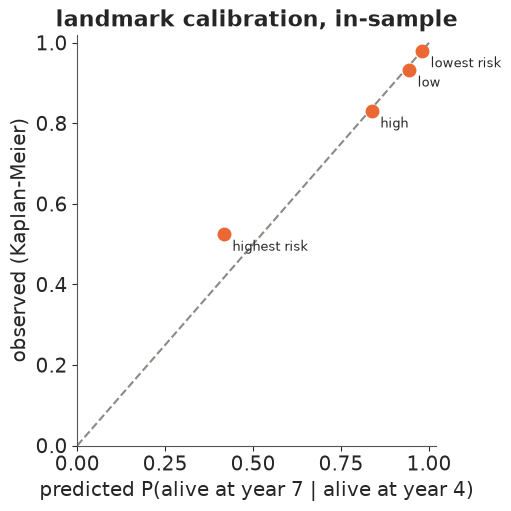

In [27]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color=GREY, ls="--")
ax.plot(calib["mean predicted P(alive at 7 y)"], calib["Kaplan-Meier P(alive at 7 y)"], "o",
        color=ORANGE, ms=9)
for label, row in calib.iterrows():
    ax.annotate(label, (row.iloc[1], row.iloc[2]), xytext=(6, -12), textcoords="offset points", fontsize=9)
ax.set(xlabel="predicted P(alive at year 7 | alive at year 4)", ylabel="observed (Kaplan-Meier)",
       xlim=(0, 1.02), ylim=(0, 1.02), title="landmark calibration, in-sample");

The predictions separate patients well: observed 3-year survival ranges from about 0.5 in
the highest-risk quartile to 0.98 in the lowest. The three lower-risk quartiles sit on the
diagonal. The highest-risk quartile is **too pessimistic** - predicted 0.42, observed about
0.52 - the same direction as the mid-follow-up misfit of the marginal curve and as patient 83
at year 2: straight lines extrapolated from steep recent slopes overstate how fast the
sickest patients will deteriorate. With about 55 patients per quartile and an in-sample
check, the gap is suggestive rather than conclusive, and it points to the same fix as
"Try it yourself" 1.

## 10 · Summary

| Question | Answer from this notebook |
|---|---|
| How does the hazard depend on bilirubin? | through the **current latent value**: $\alpha \approx 1.33$, about 2.5x the hazard per doubling |
| Why not use the baseline value? | attenuated $\alpha$, and a spurious rising baseline hazard |
| Why not last value carried forward? | treats noisy, stale snapshots as exact; here it gives a *larger* $\alpha$ - noise alone would do the opposite; the linear trajectory and visit timing are suspects |
| Why not two-stage? | plug-in trajectories: $\alpha$ attenuated and its interval too narrow |
| What does dropout do? | the observed yearly average flattens; the model's mean trajectory keeps rising |
| How is $H(T)$ computed? | Gauss-Legendre after $u = t^k$, checked against SciPy and a closed form |
| Centred or non-centred? | neither: *hierarchically* centred (means inside the MvNormal) - 20x the ESS of centred for the population means; non-centred worst. No divergences in any of them |
| Does D-penicillamine work? | no detectable effect on progression or on the hazard |
| What is it for? | dynamic predictions that update with every new measurement; calibrated except for the highest-risk quartile (too pessimistic) |

## Try it yourself

1. **A curved trajectory.** Replace the straight line by a natural cubic spline in $t$ with
   two or three basis functions, each with a random coefficient (a 3- or 4-dimensional
   `LKJCholeskyCov`). The quadrature needs no change beyond evaluating $m_i(t)$ at the nodes.
   Do the residuals before death disappear? Does $\alpha$ move towards the LOCF estimate, and
   does patient 38's forecast improve?
2. **Slope association.** Let the hazard depend on the current *rate of change* too:
   $\eta_i(t) + \alpha\,m_i(t) + \alpha_s\,m_i'(t)$. With linear trajectories $m_i'(t)$ is
   the patient's slope. Is $\alpha_s$ distinguishable from zero once the current level is in
   the model?
3. **Competing risks.** Model transplant as a second event with its own Weibull hazard
   sharing the same trajectory (a second $\alpha$). Compute the cumulative incidence of death
   for patient 70 at year 8, and compare it with $1 - S$ from the cause-specific model used
   here. Why is the cause-specific version the larger of the two?